In [1]:
import pandas as pd

df = pd.read_csv('../data/zhvi_2bedroom_city.csv')
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275085.787434,276578.751949,...,787296.953110,789102.218328,791607.848906,795165.928435,797276.689940,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,175285.760085,175561.011360,...,778000.675837,773504.032207,765447.565253,758803.724993,752480.072463,747531.958893,744705.962636,743935.196104,745127.411825,746981.876773
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,72931.663043,72885.575548,...,180481.303406,179808.102560,178631.372455,177295.052029,175666.545609,174018.436290,172615.616215,171359.918736,170144.915556,168949.943582
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,106338.913129,106395.336063,...,300962.138131,302336.511269,303288.588905,304244.883696,304779.002563,305288.262704,306126.565555,307255.092568,308795.157170,310828.855471
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,58752.302134,58803.501528,...,148430.035864,147853.161803,146833.450272,145558.292794,144213.101868,143329.284106,143019.328555,142691.135173,142133.560236,141192.421127


In [2]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist()[:10], "...")  # Show first 10 columns
print(f"\nTotal columns: {len(df.columns)}")


Dataset Shape: (11236, 318)

Column Names:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName', '2000-01-31', '2000-02-29'] ...

Total columns: 318


In [3]:
# Check for New York in the dataset
print("Unique Region Names (first 20):")
print(df['RegionName'].unique()[:20])
print("\nChecking for New York:")
ny_regions = df[df['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_regions)} regions with 'New York' in name:")
print(ny_regions[['RegionName', 'StateName', 'CountyName']].to_string())


Unique Region Names (first 20):
['New York' 'Los Angeles' 'Houston' 'Chicago' 'San Antonio' 'Philadelphia'
 'Phoenix' 'Las Vegas' 'San Diego' 'Dallas' 'Austin' 'San Jose'
 'Jacksonville' 'Charlotte' 'Indianapolis' 'Fort Worth' 'Orlando'
 'San Francisco' 'Tucson' 'Columbus']

Checking for New York:
Found 3 regions with 'New York' in name:
          RegionName StateName     CountyName
0           New York        NY  Queens County
1119   West New York        NJ  Hudson County
9104  New York Mills        NY  Oneida County


In [4]:
import matplotlib.pyplot as plt

# Filter for New York and save to house_prices_df
house_prices_df = df[df["RegionName"] == "New York"].copy()
print(f"Selected region: {house_prices_df[['RegionName', 'StateName', 'CountyName']].values}")

# Drop non-date columns
price_data = house_prices_df.loc[:, "2000-01-31":]

# Convert to long format
price_long = price_data.melt(var_name="Date", value_name="MedianPrice")

# Convert Date column to datetime
price_long["Date"] = pd.to_datetime(price_long["Date"])

# Sort by date
price_long = price_long.sort_values("Date")

# Basic stats on the price data
print(f"\nPrice data statistics:")
print(price_long['MedianPrice'].describe())
print(f"\nDate range: {price_long['Date'].min()} to {price_long['Date'].max()}")
print(f"Total data points: {len(price_long)}")
print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")

Selected region: [['New York' 'NY' 'Queens County']]

Price data statistics:
count       309.000000
mean     564969.632456
std      153412.073462
min      275085.787434
25%      463043.377870
50%      535672.124529
75%      731341.533344
max      808054.694407
Name: MedianPrice, dtype: float64

Date range: 2000-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 310
Missing values: 1


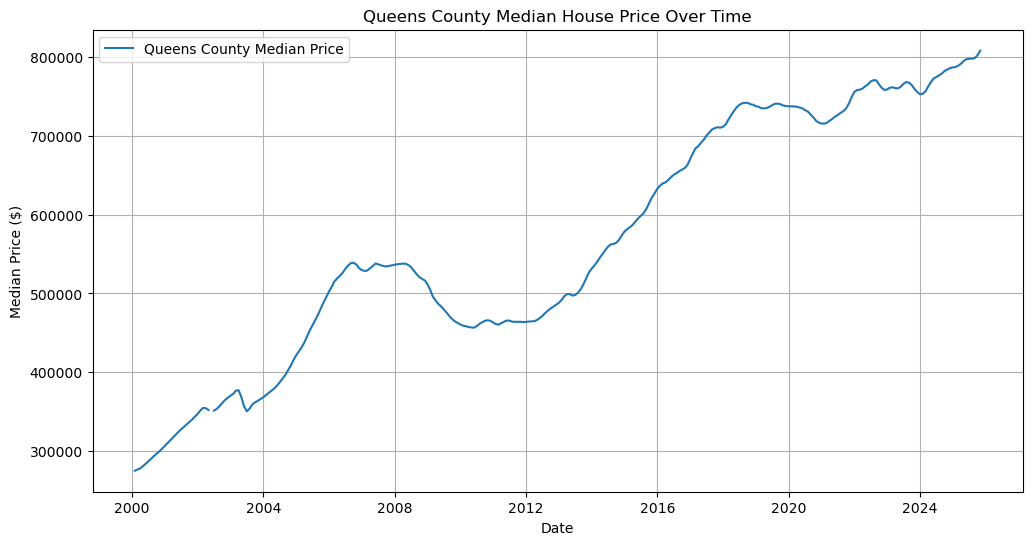

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(
    price_long["Date"], price_long["MedianPrice"], label="Queens County Median Price"
)
plt.title("Queens County Median House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
house_prices_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275085.787434,276578.751949,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407


In [7]:
house_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 0 to 0
Columns: 318 entries, RegionID to 2025-10-31
dtypes: float64(310), int64(2), object(6)
memory usage: 2.5+ KB


In [8]:
house_prices_df.describe()

,RegionID,SizeRank,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
count,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,6181.0,0.0,275085.787434,276578.751949,278055.387249,280929.370426,283845.32446,287085.522427,290526.775438,293733.610402,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,6181.0,0.0,275085.787434,276578.751949,278055.387249,280929.370426,283845.32446,287085.522427,290526.775438,293733.610402,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407
25%,6181.0,0.0,275085.787434,276578.751949,278055.387249,280929.370426,283845.32446,287085.522427,290526.775438,293733.610402,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407
50%,6181.0,0.0,275085.787434,276578.751949,278055.387249,280929.370426,283845.32446,287085.522427,290526.775438,293733.610402,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407
75%,6181.0,0.0,275085.787434,276578.751949,278055.387249,280929.370426,283845.32446,287085.522427,290526.775438,293733.610402,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407
max,6181.0,0.0,275085.787434,276578.751949,278055.387249,280929.370426,283845.32446,287085.522427,290526.775438,293733.610402,...,787296.95311,789102.218328,791607.848906,795165.928435,797276.68994,797914.736439,797934.530697,798787.336034,802244.093886,808054.694407


In [9]:
# Check for duplicates
print("Duplicate rows:", house_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", house_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [10]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())
print("\nMissing values by column:")
print(house_prices_df.isna().sum()[house_prices_df.isna().sum() > 0])

Total missing values: 1

Missing values by column:
2002-05-31    1
dtype: int64


In [11]:
# Fill missing value using forward fill
house_prices_df = house_prices_df.fillna(method='ffill', axis=1)

C:\Users\anour\AppData\Local\Temp\ipykernel_3580\2686464598.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  house_prices_df = house_prices_df.fillna(method='ffill', axis=1)


In [12]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())


Total missing values: 0


In [13]:
# Check what columns are in price_long
print("Columns:", price_long.columns.tolist())
print("\nFirst few rows:")
print(price_long.head())

Columns: ['Date', 'MedianPrice']

First few rows:
        Date    MedianPrice
0 2000-01-31  275085.787434
1 2000-02-29  276578.751949
2 2000-03-31  278055.387249
3 2000-04-30  280929.370426
4 2000-05-31  283845.324460


In [14]:
price_long.tail()

,Date,MedianPrice
305,2025-06-30,797914.736439
306,2025-07-31,797934.530697
307,2025-08-31,798787.336034
308,2025-09-30,802244.093886
309,2025-10-31,808054.694407


In [15]:
# Prepare for Prophet (needs 'ds' and 'y' columns)
price_long_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

In [16]:
# ============================================
# RENTAL PRICES PREPROCESSING
# ============================================

# Read rental prices data
df_rental = pd.read_csv('../data/RentalPricesSF.csv')
df_rental.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1246.908584,1252.271627,1257.626536,1262.924886,1267.209456,...,2179.115676,2185.023644,2190.146408,2194.924800,2199.834764,2205.337099,2210.374725,2215.644142,2221.546288,2227.217865
1,394913,1,"New York, NY",msa,NY,1999.103970,2015.402826,2026.174407,2029.399917,2025.524426,...,3311.646607,3313.350473,3312.423055,3325.707720,3343.340464,3363.969388,3372.575601,3385.404370,3396.630523,3418.606199
2,753899,2,"Los Angeles, CA",msa,CA,2456.112189,2469.291608,2481.435532,2487.011258,2492.523022,...,4241.207661,4270.945533,4296.926762,4291.027368,4295.388164,4299.242878,4305.476021,4313.492002,4324.747508,4337.564598
3,394463,3,"Chicago, IL",msa,IL,1450.896616,1452.404830,1455.069111,1462.492062,1467.452633,...,2337.587760,2352.598456,2363.024244,2372.158468,2381.283320,2391.606292,2404.487186,2410.674537,2420.950198,2426.494776
4,394514,4,"Dallas, TX",msa,TX,1378.732933,1384.622858,1389.735589,1396.782834,1402.792494,...,2301.091651,2307.138300,2308.790969,2311.375097,2313.036312,2315.010578,2315.587632,2314.677116,2319.211766,2325.361047


In [17]:
# Basic information
print("Dataset Shape:", df_rental.shape)
print("\nColumn Names (first 10):")
print(df_rental.columns.tolist()[:10])
print(f"\nTotal columns: {len(df_rental.columns)}")

Dataset Shape: (575, 135)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31']

Total columns: 135


In [18]:
# Data types and info
df_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Columns: 135 entries, RegionID to 2025-10-31
dtypes: float64(130), int64(2), object(3)
memory usage: 606.6+ KB


In [19]:
# Check for New York
print("Checking for New York:")
ny_rental = df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_rental)} regions with 'New York' in name:")
print(ny_rental[['RegionName', 'StateName']].to_string())

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [20]:
# Filter for New York and save to rental_prices_df
rental_prices_df = df_rental[df_rental['RegionName'] == 'New York, NY'].copy()
# Or try: df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)].copy()
print(f"Selected region: {rental_prices_df[['RegionName', 'StateName']].values}")
print(f"Shape: {rental_prices_df.shape}")

Selected region: [['New York, NY' 'NY']]
Shape: (1, 135)


In [21]:
# Check for duplicates
print("Duplicate rows:", rental_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", rental_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [22]:
# Check for missing values
print("Total missing values:", rental_prices_df.isna().sum().sum())


Total missing values: 0


In [23]:
# Drop non-date columns
rental_price_data = rental_prices_df.loc[:, "2015-01-31":]  # Adjust start date as needed

# Convert to long format
rental_long = rental_price_data.melt(var_name="Date", value_name="RentalPrice")

# Convert Date column to datetime
rental_long["Date"] = pd.to_datetime(rental_long["Date"])

# Sort by date
rental_long = rental_long.sort_values("Date")

# Set Date as index
rental_long = rental_long.set_index("Date")

# Basic stats on the rental data
print(f"\nRental data statistics:")
print(rental_long['RentalPrice'].describe())
print(f"\nDate range: {rental_long.index.min()} to {rental_long.index.max()}")
print(f"Total data points: {len(rental_long)}")
print(f"Missing values: {rental_long['RentalPrice'].isna().sum()}")


Rental data statistics:
count     130.000000
mean     2578.234115
std       443.291967
min      1999.103970
25%      2221.692557
50%      2411.799682
75%      2978.645755
max      3418.606199
Name: RentalPrice, dtype: float64

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 130
Missing values: 0


In [24]:
# Verify ready for time series
print("Date range:", rental_long.index.min(), "to", rental_long.index.max())
print("Total points:", len(rental_long))
print("Date is datetime:", pd.api.types.is_datetime64_any_dtype(rental_long.index))
print("No missing:", rental_long['RentalPrice'].isna().sum() == 0)
print("No duplicates:", rental_long.index.duplicated().sum() == 0)
print("Is sorted:", rental_long.index.is_monotonic_increasing)

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total points: 130
Date is datetime: True
No missing: True
No duplicates: True
Is sorted: True


In [26]:
# ============================================
# MORTGAGE RATES PREPROCESSING
# ============================================

from fredapi import Fred
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get FRED API key from environment
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Pull 30-Year Fixed Rate Mortgage, monthly data
mortgage = fred.get_series(
    "MORTGAGE30US", start_date="2015-01-01", end_date="2025-12-01"
)

# Convert to DataFrame
mortgage_df = mortgage.to_frame(name="mortgage_rate")
mortgage_df.index.name = "date"
mortgage_df.reset_index(inplace=True)

# Keep only data from 2015 onwards
mortgage_df = mortgage_df[mortgage_df["date"] >= "2015-01-01"]

# Convert date to datetime
mortgage_df["date"] = pd.to_datetime(mortgage_df["date"])

# Convert to monthly (take end of month value)
mortgage_df["month"] = mortgage_df["date"].dt.to_period("M")
mortgage_df_monthly = mortgage_df.groupby("month")["mortgage_rate"].last().reset_index()
mortgage_df_monthly["Date"] = mortgage_df_monthly["month"].dt.to_timestamp()
mortgage_df_monthly = mortgage_df_monthly.drop(columns=["month"])

# Set Date as index
mortgage_df_monthly = mortgage_df_monthly.set_index("Date")

print("Mortgage data statistics:")
print(mortgage_df_monthly['mortgage_rate'].describe())
print(f"\nDate range: {mortgage_df_monthly.index.min()} to {mortgage_df_monthly.index.max()}")
print(f"Total data points: {len(mortgage_df_monthly)}")


Mortgage data statistics:
count    132.000000
mean       4.694697
std        1.453832
min        2.670000
25%        3.640000
50%        4.045000
75%        6.327500
max        7.790000
Name: mortgage_rate, dtype: float64

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Total data points: 132


In [27]:
# ============================================
# MERGE ALL DATA
# ============================================

# Reset indices to merge on Date
price_long_reset = price_long.reset_index()
rental_long_reset = rental_long.reset_index()
mortgage_reset = mortgage_df_monthly.reset_index()

# Convert all dates to end of month for alignment
price_long_reset['Date'] = pd.to_datetime(price_long_reset['Date'])
rental_long_reset['Date'] = pd.to_datetime(rental_long_reset['Date'])
mortgage_reset['Date'] = pd.to_datetime(mortgage_reset['Date'])

# Merge house prices and rental prices first (both monthly)
merged_df = pd.merge(price_long_reset, rental_long_reset, on='Date', how='outer')

# Merge with mortgage rates
merged_df = pd.merge(merged_df, mortgage_reset, on='Date', how='outer')

# Sort by date
merged_df = merged_df.sort_values('Date')

# Filter to common date range (2015 onwards where all data exists)
merged_df = merged_df[merged_df['Date'] >= '2015-01-01']

# Set Date as index
merged_df = merged_df.set_index('Date')

print("Merged dataset shape:", merged_df.shape)
print("\nFirst few rows:")
print(merged_df.head())
print("\nLast few rows:")
print(merged_df.tail())
print("\nMissing values:")
print(merged_df.isna().sum())


Merged dataset shape: (262, 4)

First few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2015-01-01    NaN            NaN          NaN           3.66
2015-01-31  180.0  581697.621505  1999.103970            NaN
2015-02-01    NaN            NaN          NaN           3.80
2015-02-28  181.0  584074.116749  2015.402826            NaN
2015-03-01    NaN            NaN          NaN           3.69

Last few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2025-09-30  308.0  802244.093886  3396.630523            NaN
2025-10-01    NaN            NaN          NaN           6.17
2025-10-31  309.0  808054.694407  3418.606199            NaN
2025-11-01    NaN            NaN          NaN           6.23
2025-12-01    NaN            NaN          NaN           6.22

Missing values:
index            132
MedianPrice      132
RentalPrice      132
mo

In [28]:
# ============================================
# TIME SERIES FORECASTING WITH PROPHET
# ============================================

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')


In [29]:
# Prepare house prices for Prophet (needs 'ds' and 'y' columns)
house_prices_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

# Create and fit Prophet model for house prices
model_house = Prophet()
model_house.fit(house_prices_prophet)

# Create future dataframe (5 years = 60 months, 10 years = 120 months)
future_house = model_house.make_future_dataframe(periods=120, freq='M')  # 10 years forecast

# Make forecast
forecast_house = model_house.predict(future_house)

print("House Prices Forecast:")
print(f"Forecast period: {forecast_house['ds'].min()} to {forecast_house['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_house[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


20:07:46 - cmdstanpy - INFO - Chain [1] start processing
20:07:47 - cmdstanpy - INFO - Chain [1] done processing


House Prices Forecast:
Forecast period: 2000-01-31 00:00:00 to 2035-10-31 00:00:00

Last 5 forecasted values:
            ds           yhat     yhat_lower    yhat_upper
425 2035-06-30  926811.076138  533452.763685  1.337630e+06
426 2035-07-31  928500.828643  524020.393380  1.349378e+06
427 2035-08-31  930153.785293  523147.637417  1.351706e+06
428 2035-09-30  930951.294476  519093.905879  1.357594e+06
429 2035-10-31  931771.186583  517597.351726  1.369786e+06


In [30]:
# Prepare rental prices for Prophet
rental_prices_prophet = rental_long.reset_index().rename(columns={'Date': 'ds', 'RentalPrice': 'y'})

# Create and fit Prophet model for rental prices
model_rental = Prophet()
model_rental.fit(rental_prices_prophet)

# Create future dataframe (10 years forecast)
future_rental = model_rental.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_rental = model_rental.predict(future_rental)

print("Rental Prices Forecast:")
print(f"Forecast period: {forecast_rental['ds'].min()} to {forecast_rental['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_rental[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


20:07:53 - cmdstanpy - INFO - Chain [1] start processing
20:07:53 - cmdstanpy - INFO - Chain [1] done processing


Rental Prices Forecast:
Forecast period: 2015-01-31 00:00:00 to 2035-10-31 00:00:00

Last 5 forecasted values:
            ds         yhat   yhat_lower   yhat_upper
245 2035-06-30  4828.566986  3864.689580  5867.200016
246 2035-07-31  4838.219728  3864.875977  5898.772693
247 2035-08-31  4849.387148  3861.827091  5918.699310
248 2035-09-30  4864.163104  3857.752197  5945.765521
249 2035-10-31  4878.828755  3860.485430  5969.504951


In [31]:
# Optional: Forecast mortgage rates
mortgage_prophet = mortgage_df_monthly.reset_index().rename(columns={'Date': 'ds', 'mortgage_rate': 'y'})

# Create and fit Prophet model for mortgage rates
model_mortgage = Prophet()
model_mortgage.fit(mortgage_prophet)

# Create future dataframe (10 years forecast)
future_mortgage = model_mortgage.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_mortgage = model_mortgage.predict(future_mortgage)

print("Mortgage Rates Forecast:")
print(f"Forecast period: {forecast_mortgage['ds'].min()} to {forecast_mortgage['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_mortgage[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


20:07:59 - cmdstanpy - INFO - Chain [1] start processing
20:07:59 - cmdstanpy - INFO - Chain [1] done processing


Mortgage Rates Forecast:
Forecast period: 2015-01-01 00:00:00 to 2035-11-30 00:00:00

Last 5 forecasted values:
            ds       yhat  yhat_lower  yhat_upper
247 2035-07-31  14.268819   12.541413   15.845955
248 2035-08-31  14.468950   12.807997   16.132041
249 2035-09-30  14.672264   13.015142   16.257861
250 2035-10-31  14.581658   12.857809   16.211333
251 2035-11-30  14.550788   13.010983   16.126854


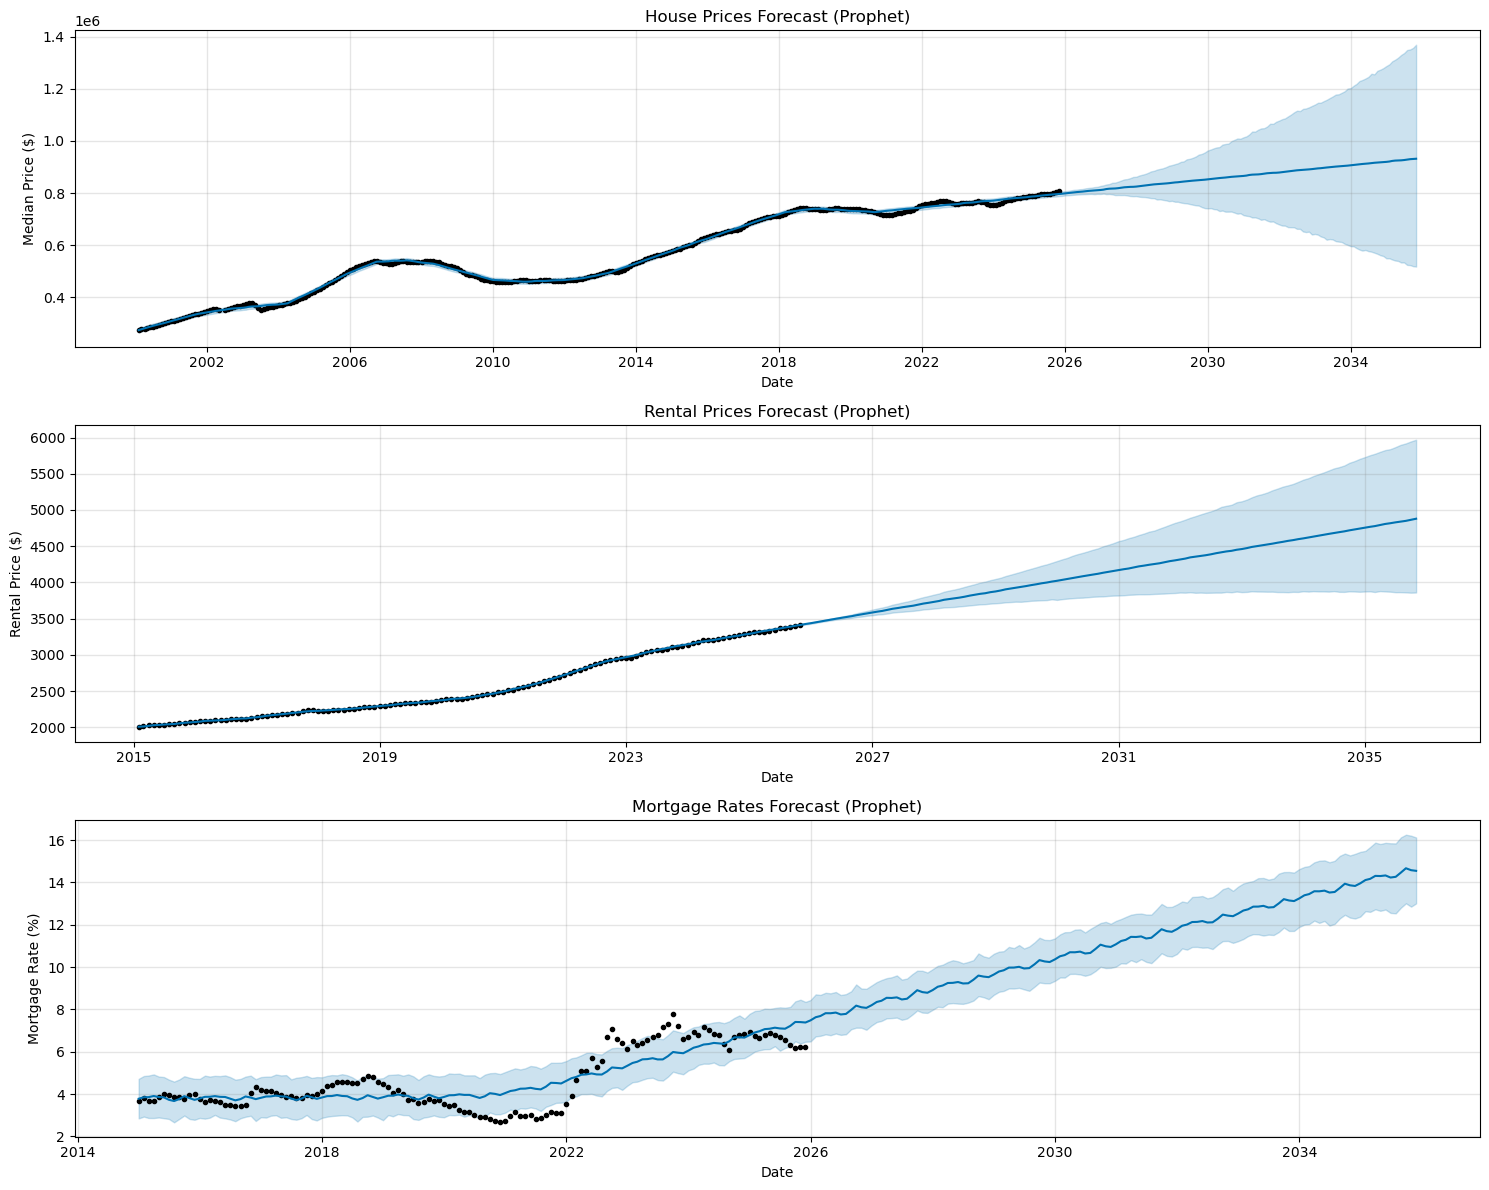

In [32]:
# Visualize forecasts
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# House prices forecast
model_house.plot(forecast_house, ax=axes[0])
axes[0].set_title('House Prices Forecast (Prophet)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Median Price ($)')

# Rental prices forecast
model_rental.plot(forecast_rental, ax=axes[1])
axes[1].set_title('Rental Prices Forecast (Prophet)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rental Price ($)')

# Mortgage rates forecast
model_mortgage.plot(forecast_mortgage, ax=axes[2])
axes[2].set_title('Mortgage Rates Forecast (Prophet)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mortgage Rate (%)')

plt.tight_layout()
plt.show()


In [33]:
# Extract forecasted values for future dates (beyond historical data)
# Get the last date from historical data
last_historical_date_house = house_prices_prophet['ds'].max()
last_historical_date_rental = rental_prices_prophet['ds'].max()
last_historical_date_mortgage = mortgage_prophet['ds'].max()

# Filter forecasts to only future dates
forecast_house_future = forecast_house[forecast_house['ds'] > last_historical_date_house].copy()
forecast_rental_future = forecast_rental[forecast_rental['ds'] > last_historical_date_rental].copy()
forecast_mortgage_future = forecast_mortgage[forecast_mortgage['ds'] > last_historical_date_mortgage].copy()

print("Future Forecasts (beyond historical data):")
print(f"\nHouse Prices - {len(forecast_house_future)} future months")
print(f"Rental Prices - {len(forecast_rental_future)} future months")
print(f"Mortgage Rates - {len(forecast_mortgage_future)} future months")


Future Forecasts (beyond historical data):

House Prices - 120 future months
Rental Prices - 120 future months
Mortgage Rates - 120 future months
